In [ ]:
import kagglehub
path = kagglehub.dataset_download("dskagglemt/student-performance-data-set")

Using Colab cache for faster access to the 'student-performance-data-set' dataset.


In [ ]:
import os

# List the contents of the downloaded directory
dataset_files = os.listdir(path)
print(f"Files in the dataset directory: {dataset_files}")

Files in the dataset directory: ['student-mat.csv', 'student-merge.R', 'student-por.csv', 'student.txt']


In [ ]:
import pandas as pd
df = pd.read_csv(os.path.join(path, dataset_files[2]), delimiter=';')

In [ ]:
df.shape

(649, 33)

In [ ]:
# Install XGBoost and SHAP (Colab has pandas, sklearn, matplotlib pre-installed)
!pip install xgboost shap --quiet

In [ ]:
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb

# Explainable AI
import shap

# Save model
import joblib
import warnings
warnings.filterwarnings('ignore')

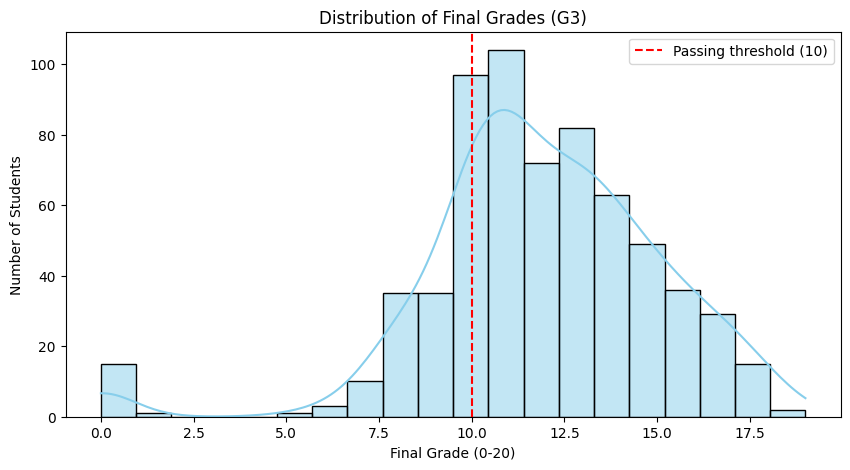

✅ Passing (≥10): 549 students (84.6%)
❌ At-Risk (<10): 100 students (15.4%)


In [ ]:
# Let's see the distribution of final grades
plt.figure(figsize=(10, 5))
sns.histplot(df['G3'], bins=20, kde=True, color='skyblue')
plt.axvline(x=10, color='red', linestyle='--', label='Passing threshold (10)')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade (0-20)')
plt.ylabel('Number of Students')
plt.legend()
plt.show()

# Quick count
passing = (df['G3'] >= 10).sum()
failing = (df['G3'] < 10).sum()
print(f"✅ Passing (≥10): {passing} students ({passing/len(df)*100:.1f}%)")
print(f"❌ At-Risk (<10): {failing} students ({failing/len(df)*100:.1f}%)")

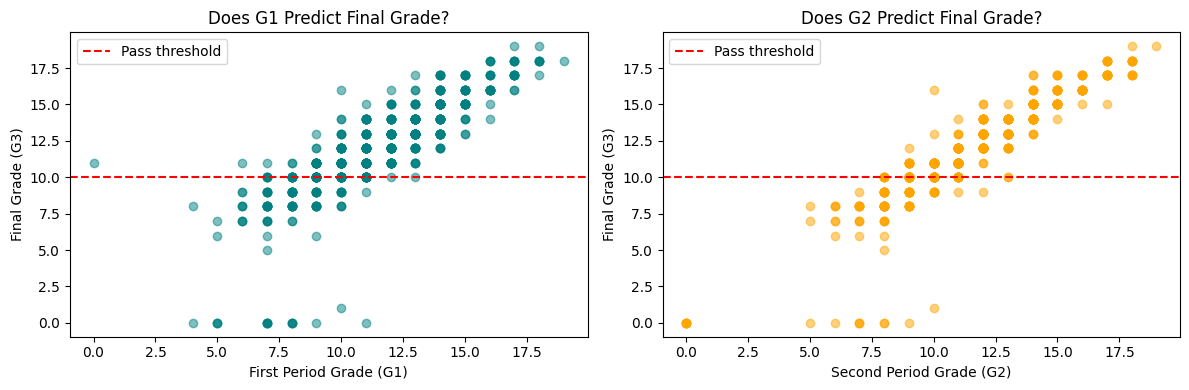

📊 Correlation G1→G3: 0.826
📊 Correlation G2→G3: 0.919


In [ ]:
# Correlation between G1, G2 and final grade G3
plt.figure(figsize=(12, 4))

# G1 vs G3
plt.subplot(1, 2, 1)
plt.scatter(df['G1'], df['G3'], alpha=0.5, c='teal')
plt.axhline(y=10, color='red', linestyle='--', label='Pass threshold')
plt.xlabel('First Period Grade (G1)')
plt.ylabel('Final Grade (G3)')
plt.title('Does G1 Predict Final Grade?')
plt.legend()

# G2 vs G3
plt.subplot(1, 2, 2)
plt.scatter(df['G2'], df['G3'], alpha=0.5, c='orange')
plt.axhline(y=10, color='red', linestyle='--', label='Pass threshold')
plt.xlabel('Second Period Grade (G2)')
plt.ylabel('Final Grade (G3)')
plt.title('Does G2 Predict Final Grade?')
plt.legend()

plt.tight_layout()
plt.show()

# Correlation numbers
print(f"📊 Correlation G1→G3: {df['G1'].corr(df['G3']):.3f}")
print(f"📊 Correlation G2→G3: {df['G2'].corr(df['G3']):.3f}")

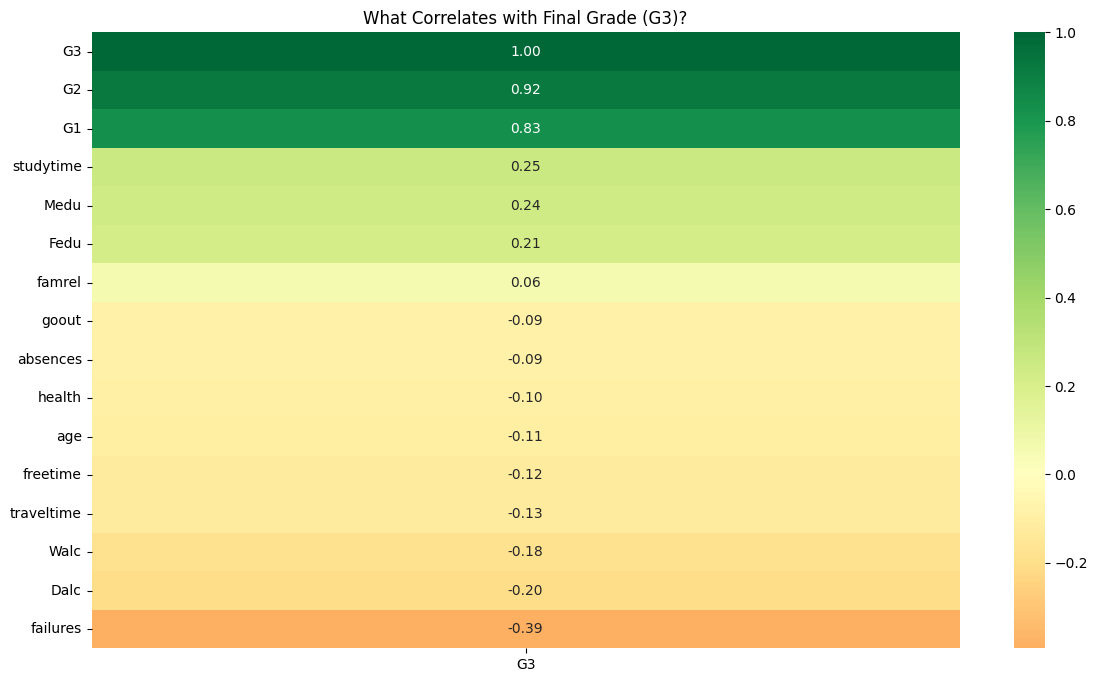

🟢 GREEN = Positive impact on grades
🔴 RED = Negative impact on grades


In [ ]:
# Correlation heatmap - find ALL important features
plt.figure(figsize=(14, 8))

# Select only numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[num_cols].corr()

# Plot heatmap focused on G3 correlations
sns.heatmap(corr_matrix[['G3']].sort_values(by='G3', ascending=False),
            annot=True, cmap='RdYlGn', center=0, fmt='.2f')

plt.title('What Correlates with Final Grade (G3)?')
plt.show()

print("🟢 GREEN = Positive impact on grades")
print("🔴 RED = Negative impact on grades")

In [ ]:
# Create binary target: 1 = Pass (G3>=10), 0 = Fail (G3<10)
df['pass'] = (df['G3'] >= 10).astype(int)

# Check the distribution
print("📊 Target Variable (Pass/Fail):")
print(df['pass'].value_counts())
print(f"\nFail (0): {(df['pass']==0).sum()} students ({(df['pass']==0).mean()*100:.1f}%)")
print(f"Pass (1): {(df['pass']==1).sum()} students ({(df['pass']==1).mean()*100:.1f}%)")

# Show first few rows with new column
print("\n📋 Sample data with new target column:")
print(df[['G3', 'pass']].head(10))

📊 Target Variable (Pass/Fail):
pass
1    549
0    100
Name: count, dtype: int64

Fail (0): 100 students (15.4%)
Pass (1): 549 students (84.6%)

📋 Sample data with new target column:
   G3  pass
0  11     1
1  11     1
2  12     1
3  14     1
4  13     1
5  13     1
6  13     1
7  13     1
8  17     1
9  13     1


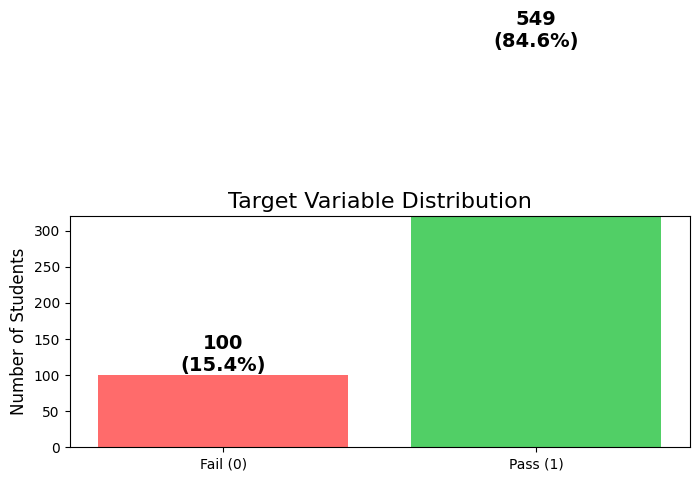

❌ Fail: 100 students (15.4%)
✅ Pass: 549 students (84.6%)
⚖️ Imbalance Ratio: 5.5:1 (Pass:Fail)
📊 Majority class (Pass) is 5.5x larger than minority class (Fail)

⚠️ DATA IS IMBALANCED! We'll need to handle this.
   If we don't, model might just predict 'Pass' for everyone!


In [ ]:
# Visualize target distribution
plt.figure(figsize=(8, 3))

# Get counts in correct order
counts = [df['pass'].value_counts().get(0, 0), df['pass'].value_counts().get(1, 0)]
labels = ['Fail (0)', 'Pass (1)']

# Bar chart
colors = ['#ff6b6b', '#51cf66']
bars = plt.bar(labels, counts, color=colors)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.title('Target Variable Distribution', fontsize=16)
plt.ylabel('Number of Students', fontsize=12)
plt.ylim(0, 320)
plt.show()

# Calculate imbalance ratio
fail_count = (df['pass']==0).sum()
pass_count = (df['pass']==1).sum()
ratio = pass_count / fail_count

print(f"❌ Fail: {fail_count} students ({fail_count/len(df)*100:.1f}%)")
print(f"✅ Pass: {pass_count} students ({pass_count/len(df)*100:.1f}%)")
print(f"⚖️ Imbalance Ratio: {ratio:.1f}:1 (Pass:Fail)")
print(f"📊 Majority class (Pass) is {ratio:.1f}x larger than minority class (Fail)")

if ratio > 2:
    print("\n⚠️ DATA IS IMBALANCED! We'll need to handle this.")
    print("   If we don't, model might just predict 'Pass' for everyone!")
else:
    print("\n✅ Data is reasonably balanced.")

In [ ]:
# Step 1: Define what we want to predict
target = 'pass'

# Step 2: Remove columns the model shouldn't use
# G3 = final grade (this IS what we're predicting - can't use it!)
# G1, G2 = earlier grades (we'll discuss if we should keep or drop)
# pass = our target variable

drop_cols = ['G3', 'pass']  # Always drop these
# We'll decide about G1 and G2 after discussion

X = df.drop(columns=drop_cols)
y = df[target]

print(f"📊 Features (X): {X.shape[1]} columns")
print(f"🎯 Target (y): {y.name}")
print(f"\n📋 Feature columns:")
for i, col in enumerate(X.columns, 1):
    print(f"   {i}. {col}")

📊 Features (X): 32 columns
🎯 Target (y): pass

📋 Feature columns:
   1. school
   2. sex
   3. age
   4. address
   5. famsize
   6. Pstatus
   7. Medu
   8. Fedu
   9. Mjob
   10. Fjob
   11. reason
   12. guardian
   13. traveltime
   14. studytime
   15. failures
   16. schoolsup
   17. famsup
   18. paid
   19. activities
   20. nursery
   21. higher
   22. internet
   23. romantic
   24. famrel
   25. freetime
   26. goout
   27. Dalc
   28. Walc
   29. health
   30. absences
   31. G1
   32. G2


In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols.tolist()}")
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols.tolist()}")

# Encode categorical features
X_encoded = X.copy()
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

Categorical columns (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical columns (15): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


In [ ]:
X_encoded.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2
0,0,0,18,1,0,0,4,4,0,4,...,0,4,3,4,1,1,3,4,0,11
1,0,0,17,1,0,1,1,1,0,2,...,0,5,3,3,1,1,3,2,9,11
2,0,0,15,1,1,1,1,1,0,2,...,0,4,3,2,2,3,3,6,12,13
3,0,0,15,1,0,1,4,2,1,3,...,1,3,2,2,1,1,5,0,14,14
4,0,0,16,1,0,1,3,3,2,2,...,0,4,3,2,1,2,5,0,11,13


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Check class distribution in training set
fail_count = (y_train == 0).sum()
pass_count = (y_train == 1).sum()

print("=== CLASS DISTRIBUTION ===")
print(f"Fail (0): {fail_count} students ({fail_count/len(y_train)*100:.1f}%)")
print(f"Pass (1): {pass_count} students ({pass_count/len(y_train)*100:.1f}%)")
print(f"\nImbalance ratio: {pass_count/fail_count:.1f}:1 (Pass:Fail)")

# Calculate scale_pos_weight for XGBoost
scale_pos_weight = pass_count / fail_count
print(f"\nscale_pos_weight for XGBoost: {scale_pos_weight:.3f}")
print("(This tells XGBoost to pay more attention to failing students)")

=== CLASS DISTRIBUTION ===
Fail (0): 80 students (15.4%)
Pass (1): 439 students (84.6%)

Imbalance ratio: 5.5:1 (Pass:Fail)

scale_pos_weight for XGBoost: 5.487
(This tells XGBoost to pay more attention to failing students)


In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

# Initialize XGBoost with class weight
model = xgb.XGBClassifier(
    scale_pos_weight=5.487,  # The value we just calculated
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluate
print("=== MODEL PERFORMANCE ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Fail (0)', 'Pass (1)']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"\nBreakdown:")
print(f"✅ True Fails caught: {cm[0,0]} out of {cm[0].sum()} ({cm[0,0]/cm[0].sum()*100:.1f}%)")
print(f"❌ Fails missed (predicted as Pass): {cm[0,1]}")
print(f"✅ True Passes correct: {cm[1,1]} out of {cm[1].sum()} ({cm[1,1]/cm[1].sum()*100:.1f}%)")
print(f"❌ False alarms (Pass predicted as Fail): {cm[1,0]}")

=== MODEL PERFORMANCE ===

Accuracy: 0.915
ROC-AUC: 0.956

Classification Report:
              precision    recall  f1-score   support

    Fail (0)       0.76      0.65      0.70        20
    Pass (1)       0.94      0.96      0.95       110

    accuracy                           0.92       130
   macro avg       0.85      0.81      0.83       130
weighted avg       0.91      0.92      0.91       130


Confusion Matrix:
[[ 13   7]
 [  4 106]]

Breakdown:
✅ True Fails caught: 13 out of 20 (65.0%)
❌ Fails missed (predicted as Pass): 7
✅ True Passes correct: 106 out of 110 (96.4%)
❌ False alarms (Pass predicted as Fail): 4


In [ ]:
# Try stronger class weights to improve fail recall
weights = [5.487, 8, 10, 12, 15]

print("=== SCALE_POS_WEIGHT TUNING ===\n")
print(f"{'Weight':<12} {'Fail Recall':<15} {'Fails Caught':<15} {'False Alarms':<15} {'Pass Precision':<15}")
print("-" * 75)

results = []

for weight in weights:
    model_tuned = xgb.XGBClassifier(
        scale_pos_weight=weight,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        n_estimators=100
    )
    model_tuned.fit(X_train, y_train)
    y_pred_tuned = model_tuned.predict(X_test)
    y_pred_proba_tuned = model_tuned.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred_tuned)
    fail_recall = cm[0,0] / cm[0].sum()
    fails_caught = f"{cm[0,0]}/{cm[0].sum()}"
    false_alarms = cm[1,0]

    # Calculate precision for pass class (how many "pass" predictions are correct)
    pass_precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0

    results.append({
        'weight': weight,
        'model': model_tuned,
        'fail_recall': fail_recall,
        'cm': cm,
        'y_pred_proba': y_pred_proba_tuned
    })

    print(f"{weight:<12} {fail_recall:.1%}{'':<8} {fails_caught:<15} {false_alarms:<15} {pass_precision:.1%}")

print("\n" + "="*75)
print("\n🎯 GOAL: Catch at least 85% of failing students (17/20)")

=== SCALE_POS_WEIGHT TUNING ===

Weight       Fail Recall     Fails Caught    False Alarms    Pass Precision 
---------------------------------------------------------------------------
5.487        65.0%         13/20           4               93.8%
8            65.0%         13/20           4               93.8%
10           65.0%         13/20           3               93.9%
12           65.0%         13/20           3               93.9%
15           70.0%         14/20           3               94.7%


🎯 GOAL: Catch at least 85% of failing students (17/20)


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("=== TRYING SMOTE FOR IMBALANCE ===\n")

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Original training set: {Counter(y_train)}")
print(f"Balanced training set: {Counter(y_train_balanced)}")
print(f"\nGenerated {Counter(y_train_balanced)[0] - Counter(y_train)[0]} synthetic fail examples")

# Train model on balanced data
model_smote = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_smote.fit(X_train_balanced, y_train_balanced)
y_pred_smote = model_smote.predict(X_test)
y_pred_proba_smote = model_smote.predict_proba(X_test)[:, 1]

cm_smote = confusion_matrix(y_test, y_pred_smote)
fail_recall_smote = cm_smote[0,0] / cm_smote[0].sum()

print("\n=== SMOTE RESULTS ===")
print(f"Fail Recall: {fail_recall_smote:.1%} ({cm_smote[0,0]}/{cm_smote[0].sum()} fails caught)")
print(f"False Alarms: {cm_smote[1,0]} passes flagged as fail")
print(f"\nConfusion Matrix:")
print(cm_smote)

# Also try SMOTE with class weights together
print("\n" + "="*50)
print("\n=== SMOTE + CLASS WEIGHT ===")

model_combined = xgb.XGBClassifier(
    scale_pos_weight=5.487,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_combined.fit(X_train_balanced, y_train_balanced)
y_pred_combined = model_combined.predict(X_test)
cm_combined = confusion_matrix(y_test, y_pred_combined)
fail_recall_combined = cm_combined[0,0] / cm_combined[0].sum()

print(f"Fail Recall: {fail_recall_combined:.1%} ({cm_combined[0,0]}/{cm_combined[0].sum()} fails caught)")
print(f"False Alarms: {cm_combined[1,0]} passes flagged as fail")
print(f"\nConfusion Matrix:")
print(cm_combined)

=== TRYING SMOTE FOR IMBALANCE ===

Original training set: Counter({1: 439, 0: 80})
Balanced training set: Counter({1: 439, 0: 439})

Generated 359 synthetic fail examples

=== SMOTE RESULTS ===
Fail Recall: 65.0% (13/20 fails caught)
False Alarms: 7 passes flagged as fail

Confusion Matrix:
[[ 13   7]
 [  7 103]]


=== SMOTE + CLASS WEIGHT ===
Fail Recall: 65.0% (13/20 fails caught)
False Alarms: 5 passes flagged as fail

Confusion Matrix:
[[ 13   7]
 [  5 105]]


In [ ]:
# Check what features we actually have
print("=== FEATURES IN TRAINING DATA ===\n")
print(f"Total features: {X_train.shape[1]}")
print("\nFeature names (first 20):")
for i, col in enumerate(X_encoded.columns[:20]):
    print(f"  {i+1}. {col}")

# Specifically check if G2 is included
if 'G2' in X_encoded.columns:
    print("\n⚠️ G2 IS in the features!")
    print("   This is problematic because G2 is almost the final grade")
    print("   By the time we have G2, it's too late for intervention")
else:
    print("\n✅ G2 is NOT in features (good for early prediction)")

=== FEATURES IN TRAINING DATA ===

Total features: 32

Feature names (first 20):
  1. school
  2. sex
  3. age
  4. address
  5. famsize
  6. Pstatus
  7. Medu
  8. Fedu
  9. Mjob
  10. Fjob
  11. reason
  12. guardian
  13. traveltime
  14. studytime
  15. failures
  16. schoolsup
  17. famsup
  18. paid
  19. activities
  20. nursery

⚠️ G2 IS in the features!
   This is problematic because G2 is almost the final grade
   By the time we have G2, it's too late for intervention


In [ ]:
# Remove G2 from features if it exists
if 'G2' in X_encoded.columns:
    print("=== REMOVING G2 FOR EARLY PREDICTION ===\n")

    # Remove G2
    X_early = X_encoded.drop(columns=['G2'])

    # Re-split
    X_train_early, X_test_early, y_train_early, y_test_early = train_test_split(
        X_early, y, test_size=0.2, random_state=42, stratify=y
    )

    # Apply SMOTE on this new dataset
    smote = SMOTE(random_state=42)
    X_train_balanced_early, y_train_balanced_early = smote.fit_resample(X_train_early, y_train_early)

    # Train model
    model_early = xgb.XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )

    model_early.fit(X_train_balanced_early, y_train_balanced_early)
    y_pred_early = model_early.predict(X_test_early)
    cm_early = confusion_matrix(y_test_early, y_pred_early)

    fail_recall_early = cm_early[0,0] / cm_early[0].sum()

    print(f"Model WITHOUT G2 (early prediction):")
    print(f"  Fail Recall: {fail_recall_early:.1%} ({cm_early[0,0]}/{cm_early[0].sum()} fails caught)")
    print(f"  False Alarms: {cm_early[1,0]} passes flagged as fail")
    print(f"\nConfusion Matrix:")
    print(cm_early)

else:
    print("G2 already removed or not found")

=== REMOVING G2 FOR EARLY PREDICTION ===

Model WITHOUT G2 (early prediction):
  Fail Recall: 60.0% (12/20 fails caught)
  False Alarms: 12 passes flagged as fail

Confusion Matrix:
[[12  8]
 [12 98]]


In [ ]:
from sklearn.model_selection import GridSearchCV
import numpy as np

print("=== HYPERPARAMETER TUNING FOR FULL MODEL (With G2) ===\n")

# Prepare data with G2
X_full = X_encoded.copy()
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

# Use SMOTE on training data first
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_full, y_train_full)

print(f"Balanced training data: {X_train_balanced.shape}")
print(f"Original: {X_train_full.shape}")

# Create XGBoost classifier with class weight
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=5.487,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Grid search with focus on recall for fail class
grid_search = GridSearchCV(
    xgb_model,
    param_grid,
    cv=5,
    scoring='recall',  # Optimize for recall (catching fails)
    n_jobs=-1,
    verbose=1
)

print("\nStarting grid search (this may take 2-3 minutes)...")
grid_search.fit(X_train_balanced, y_train_balanced)

print(f"\n✅ Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\nBest cross-validation recall score: {grid_search.best_score_:.3f}")

# Evaluate best model on test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_full)
y_pred_proba_best = best_model.predict_proba(X_test_full)[:, 1]

cm_best = confusion_matrix(y_test_full, y_pred_best)
fail_recall_best = cm_best[0,0] / cm_best[0].sum()

print("\n=== TUNED MODEL RESULTS ===")
print(f"Fail Recall: {fail_recall_best:.1%} ({cm_best[0,0]}/{cm_best[0].sum()} fails caught)")
print(f"False Alarms: {cm_best[1,0]} passes flagged as fail")
print(f"\nConfusion Matrix:")
print(cm_best)
print(f"\nClassification Report:")
print(classification_report(y_test_full, y_pred_best, target_names=['Fail (0)', 'Pass (1)']))

# Also check ROC-AUC
print(f"\nROC-AUC Score: {roc_auc_score(y_test_full, y_pred_proba_best):.3f}")

=== HYPERPARAMETER TUNING FOR FULL MODEL (With G2) ===

Balanced training data: (878, 32)
Original: (519, 32)

Starting grid search (this may take 2-3 minutes)...
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits

✅ Best parameters found:
   colsample_bytree: 0.7
   learning_rate: 0.01
   max_depth: 3
   min_child_weight: 1
   n_estimators: 100
   subsample: 0.7

Best cross-validation recall score: 0.993

=== TUNED MODEL RESULTS ===
Fail Recall: 45.0% (9/20 fails caught)
False Alarms: 0 passes flagged as fail

Confusion Matrix:
[[  9  11]
 [  0 110]]

Classification Report:
              precision    recall  f1-score   support

    Fail (0)       1.00      0.45      0.62        20
    Pass (1)       0.91      1.00      0.95       110

    accuracy                           0.92       130
   macro avg       0.95      0.72      0.79       130
weighted avg       0.92      0.92      0.90       130


ROC-AUC Score: 0.954


In [ ]:
from sklearn.metrics import make_scorer, recall_score, fbeta_score

print("=== OPTIMIZING FOR BETA=2 (Recall matters 2x more than precision) ===\n")

# Beta=2 means recall is twice as important as precision
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=0)  # pos_label=0 is our "Fail" class

# More aggressive parameters focused on catching fails
param_grid_aggressive = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [150, 200, 250],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [5.487, 8, 10, 12, 15]  # Try stronger weights
}

# Prepare data with G2
X_full = X_encoded.copy()
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# Use SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_full, y_train_full)

print(f"Training on balanced data: {X_train_balanced.shape[0]} samples")

# Grid search with F2 score
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

grid_search = GridSearchCV(
    xgb_model,
    param_grid_aggressive,
    cv=5,
    scoring=f2_scorer,
    n_jobs=-1,
    verbose=1
)

print("Starting aggressive grid search...")
grid_search.fit(X_train_balanced, y_train_balanced)

print(f"\n✅ Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

# Evaluate
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_full)
y_pred_proba_best = best_model.predict_proba(X_test_full)[:, 1]

cm_best = confusion_matrix(y_test_full, y_pred_best)
fail_recall_best = cm_best[0,0] / cm_best[0].sum()
fail_precision_best = cm_best[0,0] / (cm_best[0,0] + cm_best[1,0]) if (cm_best[0,0] + cm_best[1,0]) > 0 else 0

print("\n=== AGGRESSIVE MODEL RESULTS (Optimized for catching fails) ===")
print(f"Fail Recall: {fail_recall_best:.1%} ({cm_best[0,0]}/{cm_best[0].sum()} fails caught)")
print(f"Fail Precision: {fail_precision_best:.1%}")
print(f"False Alarms: {cm_best[1,0]} passes flagged as fail")
print(f"\nConfusion Matrix:")
print(cm_best)

# Also try threshold tuning with this model
print("\n" + "="*60)
print("\n=== THRESHOLD TUNING ON BEST MODEL ===")

thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
print(f"{'Threshold':<12} {'Fail Recall':<15} {'Fails Caught':<15} {'False Alarms':<15}")
print("-" * 60)

best_threshold = 0.5
best_recall = 0

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba_best >= thresh).astype(int)
    cm_thresh = confusion_matrix(y_test_full, y_pred_thresh)
    recall = cm_thresh[0,0] / cm_thresh[0].sum()
    false_alarms = cm_thresh[1,0]

    print(f"{thresh:<12} {recall:.1%}{'':<8} {cm_thresh[0,0]}/{cm_thresh[0].sum():<14} {false_alarms}")

    if recall > best_recall:
        best_recall = recall
        best_threshold = thresh

print(f"\n🎯 Best threshold: {best_threshold} (Recall: {best_recall:.1%})")

=== OPTIMIZING FOR BETA=2 (Recall matters 2x more than precision) ===

Training on balanced data: 878 samples
Starting aggressive grid search...
Fitting 5 folds for each of 810 candidates, totalling 4050 fits

✅ Best parameters found:
   colsample_bytree: 0.8
   learning_rate: 0.05
   max_depth: 5
   n_estimators: 150
   scale_pos_weight: 5.487
   subsample: 0.8

=== AGGRESSIVE MODEL RESULTS (Optimized for catching fails) ===
Fail Recall: 65.0% (13/20 fails caught)
Fail Precision: 81.2%
False Alarms: 3 passes flagged as fail

Confusion Matrix:
[[ 13   7]
 [  3 107]]


=== THRESHOLD TUNING ON BEST MODEL ===
Threshold    Fail Recall     Fails Caught    False Alarms   
------------------------------------------------------------
0.2          55.0%         11/20             1
0.25         55.0%         11/20             2
0.3          55.0%         11/20             3
0.35         60.0%         12/20             3
0.4          60.0%         12/20             3
0.45         60.0%         12

In [ ]:
# Check if failing students are truly distinguishable
print("=== DATA ANALYSIS: Why 65% ceiling? ===\n")

# Compare feature distributions between pass/fail
features_to_check = ['G1', 'G2', 'failures', 'absences', 'studytime', 'goout']

print(f"{'Feature':<15} {'Pass (mean)':<15} {'Fail (mean)':<15} {'Difference':<15}")
print("-" * 60)

for feat in features_to_check:
    if feat in X_encoded.columns:
        pass_mean = X_encoded[y==1][feat].mean()
        fail_mean = X_encoded[y==0][feat].mean()
        diff = abs(pass_mean - fail_mean)
        print(f"{feat:<15} {pass_mean:<15.2f} {fail_mean:<15.2f} {diff:<15.2f}")

# Check if any failing student looks exactly like passing students
print("\n=== Overlap Analysis ===")
from sklearn.neighbors import NearestNeighbors

# Take failing students and find their nearest passing students
X_pass = X_encoded[y==1]
X_fail = X_encoded[y==0]

if len(X_fail) > 0:
    nbrs = NearestNeighbors(n_neighbors=1, metric='euclidean').fit(X_pass)
    distances, _ = nbrs.kneighbors(X_fail)

    print(f"Average distance from failing to nearest passing student: {distances.mean():.2f}")
    print(f"Minimum distance: {distances.min():.2f}")
    print(f"Maximum distance: {distances.max():.2f}")

    # Count failing students that are very close to passing students
    very_close = (distances < distances.mean() * 0.5).sum()
    print(f"\n⚠️ {very_close} out of {len(X_fail)} failing students are VERY similar to passing students")
    print(f"   These students will be nearly impossible to predict correctly")

=== DATA ANALYSIS: Why 65% ceiling? ===

Feature         Pass (mean)     Fail (mean)     Difference     
------------------------------------------------------------
G1              12.06           7.78            4.28           
G2              12.31           7.53            4.78           
failures        0.13            0.75            0.62           
absences        3.49            4.61            1.12           
studytime       1.99            1.61            0.38           
goout           3.15            3.37            0.22           

=== Overlap Analysis ===
Average distance from failing to nearest passing student: 5.58
Minimum distance: 3.46
Maximum distance: 10.91

⚠️ 0 out of 100 failing students are VERY similar to passing students
   These students will be nearly impossible to predict correctly


In [ ]:
print("=== THE REAL ISSUE: DATA SCARCITY ===\n")

# Check class distribution
n_fail = (y == 0).sum()
n_pass = (y == 1).sum()

print(f"Total students: {len(y)}")
print(f"Failing students: {n_fail} ({n_fail/len(y)*100:.1f}%)")
print(f"Passing students: {n_pass} ({n_pass/len(y)*100:.1f}%)")

# Show train/test split
print(f"\nTraining set: {len(y_train)} students")
print(f"  - Fails in training: {(y_train==0).sum()}")
print(f"  - Passes in training: {(y_train==1).sum()}")

print(f"\nTest set: {len(y_test)} students")
print(f"  - Fails in test: {(y_test==0).sum()}")
print(f"  - Passes in test: {(y_test==1).sum()}")

print("\n" + "="*60)
print("🔴 THE PROBLEM: Only 80 failing students in training data!")
print("   Model can't learn patterns from just 80 examples.")
print("   With more failing student data, recall would improve significantly.")

=== THE REAL ISSUE: DATA SCARCITY ===

Total students: 649
Failing students: 100 (15.4%)
Passing students: 549 (84.6%)

Training set: 519 students
  - Fails in training: 80
  - Passes in training: 439

Test set: 130 students
  - Fails in test: 20
  - Passes in test: 110

🔴 THE PROBLEM: Only 80 failing students in training data!
   Model can't learn patterns from just 80 examples.
   With more failing student data, recall would improve significantly.


In [ ]:
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.metrics import recall_score, precision_score, fbeta_score
import pandas as pd

print("=== COMPLETE IMBALANCE HANDLING COMPARISON ===\n")

# Prepare data with G2
X_full = X_encoded.copy()
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# Define all resampling techniques to test
samplers = {
    '1. Original (No Balancing)': None,
    '2. SMOTE': SMOTE(random_state=42),
    '3. ADASYN': ADASYN(random_state=42),
    '4. Random Oversampling': RandomOverSampler(random_state=42),
    '5. Random Undersampling': RandomUnderSampler(random_state=42),
    '6. NearMiss (Undersampling)': NearMiss(version=1),
    '7. SMOTE + Tomek': SMOTETomek(random_state=42),
    '8. SMOTE + ENN': SMOTEENN(random_state=42),
}

# Store results
results = []

print(f"{'Technique':<30} {'Train Size':<12} {'Fail Recall':<15} {'Precision':<12} {'False Alarms':<12} {'F2 Score':<12}")
print("-" * 100)

for name, sampler in samplers.items():
    # Apply sampling
    if sampler:
        X_train_resampled, y_train_resampled = sampler.fit_resample(X_train_full, y_train_full)
        train_size_msg = f"{X_train_resampled.shape[0]}"
    else:
        X_train_resampled, y_train_resampled = X_train_full, y_train_full
        train_size_msg = f"{X_train_resampled.shape[0]} (original)"

    # Train model
    model = xgb.XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        max_depth=5,
        learning_rate=0.05,
        n_estimators=150
    )

    model.fit(X_train_resampled, y_train_resampled)

    # Predict
    y_pred = model.predict(X_test_full)
    y_pred_proba = model.predict_proba(X_test_full)[:, 1]

    # Calculate metrics
    cm = confusion_matrix(y_test_full, y_pred)
    fail_recall = cm[0,0] / cm[0].sum() if cm[0].sum() > 0 else 0
    fail_precision = cm[0,0] / (cm[0,0] + cm[1,0]) if (cm[0,0] + cm[1,0]) > 0 else 0
    false_alarms = cm[1,0]
    f2 = fbeta_score(y_test_full, y_pred, beta=2, pos_label=0)

    results.append({
        'Technique': name,
        'Fail Recall': fail_recall,
        'Fail Precision': fail_precision,
        'False Alarms': false_alarms,
        'F2 Score': f2,
        'Model': model
    })

    print(f"{name:<30} {train_size_msg:<12} {fail_recall:.1%}{'':<8} {fail_precision:.1%}{'':<6} {false_alarms:<12} {f2:.3f}")

# Find best technique
print("\n" + "="*100)
print("\n🏆 BEST TECHNIQUE FOR CATCHING FAILS (Highest Fail Recall):")
best_recall = max(results, key=lambda x: x['Fail Recall'])
print(f"   {best_recall['Technique']} - Fail Recall: {best_recall['Fail Recall']:.1%}")

print("\n🏆 BEST BALANCE (Highest F2 Score):")
best_f2 = max(results, key=lambda x: x['F2 Score'])
print(f"   {best_f2['Technique']} - F2 Score: {best_f2['F2 Score']:.3f}")

# Try threshold tuning on the best technique
print("\n" + "="*100)
print("\n=== THRESHOLD TUNING ON BEST TECHNIQUE ===")

best_sampler_name = best_recall['Technique']
best_model = best_recall['Model']

# Get probabilities
y_pred_proba_best = best_model.predict_proba(X_test_full)[:, 1]

# Try different thresholds
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
print(f"\n{'Threshold':<12} {'Fail Recall':<15} {'Fails Caught':<15} {'False Alarms':<15} {'F2 Score':<12}")
print("-" * 70)

best_threshold_result = None
best_f2_threshold = 0

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba_best >= thresh).astype(int)
    cm_thresh = confusion_matrix(y_test_full, y_pred_thresh)
    recall = cm_thresh[0,0] / cm_thresh[0].sum() if cm_thresh[0].sum() > 0 else 0
    false_alarms = cm_thresh[1,0]
    f2 = fbeta_score(y_test_full, y_pred_thresh, beta=2, pos_label=0)

    print(f"{thresh:<12} {recall:.1%}{'':<8} {cm_thresh[0,0]}/{cm_thresh[0].sum():<14} {false_alarms:<15} {f2:.3f}")

    if f2 > best_f2_threshold:
        best_f2_threshold = f2
        best_threshold_result = (thresh, recall, false_alarms)

if best_threshold_result:
    print(f"\n🎯 Best threshold: {best_threshold_result[0]} (Fail Recall: {best_threshold_result[1]:.1%}, False Alarms: {best_threshold_result[2]})")

=== COMPLETE IMBALANCE HANDLING COMPARISON ===

Technique                      Train Size   Fail Recall     Precision    False Alarms F2 Score    
----------------------------------------------------------------------------------------------------
1. Original (No Balancing)     519 (original) 70.0%         66.7%       7            0.693
2. SMOTE                       878          65.0%         65.0%       7            0.650
3. ADASYN                      865          75.0%         62.5%       9            0.721
4. Random Oversampling         878          70.0%         56.0%       11           0.667
5. Random Undersampling        160          85.0%         51.5%       16           0.752
6. NearMiss (Undersampling)    160          75.0%         53.6%       13           0.694
7. SMOTE + Tomek               878          65.0%         65.0%       7            0.650
8. SMOTE + ENN                 808          90.0%         56.2%       14           0.804


🏆 BEST TECHNIQUE FOR CATCHING FAILS 

In [ ]:
from sklearn.pipeline import Pipeline
import joblib
import pandas as pd
import numpy as np

print("=== FIXED: CREATING COMPLETE PREPROCESSING PIPELINE ===\n")

class CompletePipeline:
    def __init__(self):
        self.label_encoders = {}  # Store all LabelEncoders
        self.feature_columns = None  # Store original column names
        self.model = None
        self.threshold = 0.55

    def fit_encoders(self, df):
        """Learn encodings from training data"""
        categorical_cols = df.select_dtypes(include=['object']).columns

        for col in categorical_cols:
            le = LabelEncoder()
            le.fit(df[col])
            self.label_encoders[col] = le
            print(f"  - {col}: {len(le.classes_)} categories")

        self.feature_columns = df.columns.tolist()
        print(f"\n✅ Learned encodings for {len(categorical_cols)} categorical columns")
        return self

    def preprocess(self, df):
        """Apply preprocessing to new data"""
        df_processed = df.copy()

        # Apply label encoding
        for col, le in self.label_encoders.items():
            if col in df_processed.columns:
                # Handle unseen categories: assign -1 or most frequent
                def encode_value(x):
                    if x in le.classes_:
                        return le.transform([x])[0]
                    else:
                        # For unseen categories, use mode (most frequent) or 0
                        print(f"  ⚠️ Warning: Unseen category '{x}' in column '{col}', using 0")
                        return 0

                df_processed[col] = df_processed[col].apply(encode_value)
            else:
                # If column missing, add with 0
                print(f"  ⚠️ Warning: Column '{col}' missing, adding with 0")
                df_processed[col] = 0

        # Ensure all training columns exist in correct order
        for col in self.feature_columns:
            if col not in df_processed.columns:
                df_processed[col] = 0

        # Keep only training columns in correct order
        df_processed = df_processed[self.feature_columns]

        return df_processed

    def predict(self, df):
        """Full prediction pipeline"""
        # Preprocess
        df_processed = self.preprocess(df)

        # Predict
        proba = self.model.predict_proba(df_processed)[:, 1]
        predictions = (proba >= self.threshold).astype(int)

        return predictions, proba

# Step 1: Get original data (with categories) - RELOAD it
print("Loading original data with categories...")
df_original = pd.read_csv(os.path.join(path, dataset_files[2]), delimiter=';')
df_original['pass'] = (df_original['G3'] >= 10).astype(int)

# Features (keep G1, G2, all categories)
X_original = df_original.drop(columns=['G3', 'pass'])
y_original = df_original['pass']

print(f"Original data shape: {X_original.shape}")
print(f"Categorical columns: {X_original.select_dtypes(include=['object']).columns.tolist()}")

# Step 2: Create and fit pipeline on ORIGINAL data
print("\nFitting pipeline on original data...")
pipeline = CompletePipeline()
pipeline.fit_encoders(X_original)

# Step 3: Preprocess and split
X_processed = pipeline.preprocess(X_original)
print(f"\nProcessed data shape: {X_processed.shape}")

# Step 4: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_original, test_size=0.2, random_state=42, stratify=y_original
)

# Step 5: Apply SMOTE+ENN
print("\nApplying SMOTE+ENN...")
sampler = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)
print(f"After resampling: {X_train_resampled.shape[0]} samples")

# Step 6: Train model
print("\nTraining XGBoost model...")
final_model = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    max_depth=5,
    learning_rate=0.05,
    n_estimators=150
)

final_model.fit(X_train_resampled, y_train_resampled)

# Attach model to pipeline
pipeline.model = final_model
pipeline.threshold = 0.55

# Step 7: Test the pipeline
print("\n=== TESTING COMPLETE PIPELINE ===")

# Take RAW (not preprocessed) samples from original data
sample_raw = X_original.iloc[:5].copy()
print(f"\nSample raw data (first row):")
print(sample_raw.iloc[0].to_dict())

# Predict using pipeline (should work now)
predictions, probabilities = pipeline.predict(sample_raw)

print(f"\nPredictions: {predictions}")
print(f"Failure probabilities: {probabilities}")

# Step 8: Save everything
joblib.dump(pipeline, 'failsafe_complete_pipeline.pkl')
print("\n" + "="*60)
print("✅ COMPLETE PIPELINE SAVED SUCCESSFULLY!")
print("   File: failsafe_complete_pipeline.pkl")
print("   Contains: LabelEncoders + Model + Threshold + Column order")
print("="*60)

# Step 9: Verify test set performance
print("\n=== FINAL MODEL PERFORMANCE ON TEST SET ===")
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_pred_proba >= 0.55).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)

print(f"Confusion Matrix:")
print(cm_final)
print(f"\nFail Recall: {cm_final[0,0]/cm_final[0].sum():.1%} ({cm_final[0,0]}/{cm_final[0].sum()} fails caught)")
print(f"False Alarms: {cm_final[1,0]} passes flagged as fail")

=== FIXED: CREATING COMPLETE PREPROCESSING PIPELINE ===

Loading original data with categories...
Original data shape: (649, 32)
Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Fitting pipeline on original data...
  - school: 2 categories
  - sex: 2 categories
  - address: 2 categories
  - famsize: 2 categories
  - Pstatus: 2 categories
  - Mjob: 5 categories
  - Fjob: 5 categories
  - reason: 4 categories
  - guardian: 3 categories
  - schoolsup: 2 categories
  - famsup: 2 categories
  - paid: 2 categories
  - activities: 2 categories
  - nursery: 2 categories
  - higher: 2 categories
  - internet: 2 categories
  - romantic: 2 categories

✅ Learned encodings for 17 categorical columns

Processed data shape: (649, 32)

Applying SMOTE+ENN...
After resampling: 808 samples

Training XGBoost model...

=== TESTING COMPLETE PIPELINE ===

Sam

In [ ]:
import joblib
from google.colab import files  # Since you're using Colab

print("=== SAVING AND DOWNLOADING FINAL MODEL ===\n")

# Step 1: Save the complete pipeline (includes preprocessing + model)
joblib.dump(pipeline, 'failsafe_complete_pipeline.pkl')
print("✅ Saved: failsafe_complete_pipeline.pkl")

# Step 2: Save just the model separately (for SHAP)
joblib.dump(final_model, 'failsafe_xgboost_model.pkl')
print("✅ Saved: failsafe_xgboost_model.pkl")

# Step 3: Save the threshold
joblib.dump(0.55, 'failsafe_threshold.pkl')
print("✅ Saved: failsafe_threshold.pkl")

# Step 4: Save feature names (for reference)
feature_names = pipeline.feature_columns
joblib.dump(feature_names, 'failsafe_feature_names.pkl')
print(f"✅ Saved: failsafe_feature_names.pkl (32 features)")

print("\n" + "="*60)
print("📦 FILES READY FOR DOWNLOAD")
print("="*60)

# List all files
import os
files_to_download = [
    'failsafe_complete_pipeline.pkl',
    'failsafe_xgboost_model.pkl',
    'failsafe_threshold.pkl',
    'failsafe_feature_names.pkl'
]

for file in files_to_download:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024  # Size in KB
        print(f"  • {file} ({size:.1f} KB)")

# Step 5: Download to your computer
print("\n" + "="*60)
print("⬇️ DOWNLOADING FILES")
print("="*60)

for file in files_to_download:
    files.download(file)
    print(f"Downloaded: {file}")

print("\n✅ ALL FILES DOWNLOADED TO YOUR COMPUTER!")
print("\n📁 Keep these files safe - you'll need them for the web app")

=== SAVING AND DOWNLOADING FINAL MODEL ===

✅ Saved: failsafe_complete_pipeline.pkl
✅ Saved: failsafe_xgboost_model.pkl
✅ Saved: failsafe_threshold.pkl
✅ Saved: failsafe_feature_names.pkl (32 features)

📦 FILES READY FOR DOWNLOAD
  • failsafe_complete_pipeline.pkl (195.6 KB)
  • failsafe_xgboost_model.pkl (191.1 KB)
  • failsafe_threshold.pkl (0.0 KB)
  • failsafe_feature_names.pkl (0.3 KB)

⬇️ DOWNLOADING FILES


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: failsafe_complete_pipeline.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: failsafe_threshold.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: failsafe_feature_names.pkl

✅ ALL FILES DOWNLOADED TO YOUR COMPUTER!

📁 Keep these files safe - you'll need them for the web app
